In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random
from numpy import random 
%matplotlib widget

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Apr 15 21:45:00 2025

@author: AD
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random
%matplotlib widget

# test 22:18 - 22:41

"""
# ----- Paramètres de simulation -----
nombre_particules = 81     # Nombre de particules (npart)
temps_debut = 0.0             # Temps initial (temps_initial)
temps_fin = 40.0             # Temps final (temps_final)
nombre_pas_temps = 8000   
25 dt voisins 
"""
# test 2 7:13 - never dar nu sunt sigur de ce
"""
# ----- Constantes -----
profondeur_puits_LJ = 1.0     # Profondeur du puits de potentiel de Lennard-Jones (epsilon)
distance_sigma_LJ = 1.0       # Distance à laquelle le potentiel de Lennard-Jones est nul (sigma)
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 50.0       # Taille de la boîte de simulation (carrée)
masse_particule = 1.0         # Masse des particules
temperature_initiale = 0.5  # Température initiale (T_init)
temperature_max = 5.0         # (T_max)
constante_Boltzmann = 1.0     # Constante de Boltzmann (kB)


# ----- Paramètres de simulation -----
nombre_particules = 625     # Nombre de particules (npart)
temps_debut = 0.0             # Temps initial (temps_initial)
temps_fin = 40.0             # Temps final (temps_final)
nombre_pas_temps = 7000       # Nombre d'itérations (nombre_iterations)
pas_temps = (temps_fin - temps_debut) / nombre_pas_temps   # Pas de temps (pas_de_temps)
frequence_ajustement_temperature = 20 # Fréquence (en nombre de pas de temps) à laquelle ajuster la température (frequence_ajustement_T)

"""
# ----- Constantes -----
profondeur_puits_LJ = 1.0     # Profondeur du puits de potentiel de Lennard-Jones (epsilon)
distance_sigma_LJ = 1.0       # Distance à laquelle le potentiel de Lennard-Jones est nul (sigma)
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 10.0       # Taille de la boîte de simulation (carrée)
masse_particule = 1.0         # Masse des particules
constante_Boltzmann = 1.0     # Constante de Boltzmann (kB)


# ----- Paramètres de simulation -----
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 10.0       # Taille de la boîte de simulation (carrée)
temperature_initiale = 0.5  # Température initiale (T_init)
temperature_max = 5.0         # (T_max)
nombre_particules = 49   # Nombre de particules (npart)
temps_debut = 0.0             # Temps initial (temps_initial)
temps_fin = 40.0             # Temps final (temps_final)
nombre_pas_temps = 4000       # Nombre d'itérations (nombre_iterations)
pas_temps = (temps_fin - temps_debut) / nombre_pas_temps   # Pas de temps (pas_de_temps)
frequence_ajustement_temperature = 20 # Fréquence (en nombre de pas de temps) à laquelle ajuster la température (frequence_ajustement_T)


# ----- Paramètres pour la liste de voisins -----
frequence_maj_voisins = 25
facteur_distance_voisinage = 2.5 * distance_sigma_LJ * rayon_coupure_LJ # a reduire a 2.5
distance_voisinage_max = facteur_distance_voisinage * rayon_coupure_LJ
liste_voisins_particules = [[] for _ in range(nombre_particules)] # Initialisation vide (liste_voisins)

# ----- Chaleur latente -----
T_fusion = 0.5           # Température à laquelle se produit la fusion
L = 1.0                  # Chaleur latente par particule
energie_latente_totale = L * nombre_particules
energie_latente_restante = energie_latente_totale


# ----- Création du profil de température cible en fonction du temps -----
temps_ajustement = np.linspace(temps_debut, temps_fin, nombre_pas_temps)
temperature_cible_tab = np.zeros_like(temps_ajustement)

phase1_fin = int(0.25 * nombre_pas_temps)  # Montée (par exemple, 25% du temps)
phase2_fin = int(0.6 * nombre_pas_temps)   # Maintien au max (par exemple, 25% du temps)
phase3_fin = int(0.85 * nombre_pas_temps)  # Descente (par exemple, 25% du temps)
phase4_fin = nombre_pas_temps              # Maintien à T_init (le reste du temps)

temperature_cible_tab[:phase1_fin] = np.linspace(temperature_initiale, temperature_max, phase1_fin)
temperature_cible_tab[phase1_fin:phase2_fin] = temperature_max
temperature_cible_tab[phase2_fin:phase3_fin] = np.linspace(temperature_max, temperature_initiale, phase3_fin - phase2_fin)
temperature_cible_tab[phase3_fin:phase4_fin] = temperature_initiale


# ----- Initialisation des données -----
simulation_number = random.randint(1,20)
np.random.seed(simulation_number) # Pour la reproductibilité des résultats

# Tableaux pour stocker les positions et les vitesses à chaque itération
positions_particules = np.zeros((nombre_pas_temps, nombre_particules, 2)) # positions[temps, particule, coordonnée (x, y)] (positions)
vitesses_particules = np.zeros((nombre_pas_temps, nombre_particules, 2)) # vitesses[temps, particule, coordonnée (vx, vy)] (velocites)
accelerations_particules = np.zeros((nombre_particules, 2))       # Stockage des accélérations (accelerations)


# Conditions initiales : positions sur une grille carrée
cote_grille = int(np.sqrt(nombre_particules))
if cote_grille * cote_grille != nombre_particules:
    raise ValueError("Le nombre de particules doit être un carré parfait pour l'initialisation sur une grille carrée.")
espacement_grille = taille_boite_simu / cote_grille
x_grille, y_grille = np.meshgrid(np.arange(cote_grille) * espacement_grille + espacement_grille / 2, np.arange(cote_grille) * espacement_grille + espacement_grille / 2) # Centrage des particules dans les cellules
positions_particules[0] = np.column_stack((x_grille.ravel(), y_grille.ravel()))


# Initialisation des vitesses avec une norme correspondant à la température initiale et une direction aléatoire
vitesse_cible_init = np.sqrt(2 * constante_Boltzmann * temperature_initiale / masse_particule) # Utilisation directe de temperature_initiale
theta = 2 * np.pi * np.random.rand(nombre_particules)
vitesses_particules[0, :, 0] = vitesse_cible_init * np.cos(theta)
vitesses_particules[0, :, 1] = vitesse_cible_init * np.sin(theta)


# ----- Suppression du mouvement du centre de masse initial -----
vitesse_centre_masse_initial = np.sum(vitesses_particules[0], axis=0) / nombre_particules
vitesses_particules[0] -= vitesse_centre_masse_initial


# Pré-calcul des constantes de Lennard-Jones (hors des boucles)
sigma_LJ_carre = distance_sigma_LJ**2
sigma_LJ_sixieme = sigma_LJ_carre**3
sigma_LJ_douzieme = sigma_LJ_sixieme**2
facteur_force_LJ = 24 * profondeur_puits_LJ
facteur_potentiel_LJ = 4 * profondeur_puits_LJ
rayon_coupure_carre_LJ = rayon_coupure_LJ**2

def mettre_a_jour_voisins(positions_actuelles, taille_boite, distance_voisinage):
    """
    Met à jour la liste des voisins pour chaque particule.

    Args:
        positions_actuelles (np.ndarray): Tableau NumPy de taille (nombre_particules, 2) contenant les positions actuelles.
        taille_boite (float): Taille de la boîte de simulation.
        distance_voisinage (float): Distance maximale pour considérer une particule comme voisine.

    Returns:
        list: Une liste de listes, où chaque sous-liste contient les indices des voisins de la particule correspondante.
    """
    nombre_particules_local = len(positions_actuelles)
    voisins_local = [[] for _ in range(nombre_particules_local)]
    distance_voisinage_carre = distance_voisinage**2

    for i in range(nombre_particules_local):
        for j in range(i + 1, nombre_particules_local):
            # Vecteur de distance entre les particules i et j
            dx = positions_actuelles[i] - positions_actuelles[j]
            dx = dx - taille_boite * np.round(dx / taille_boite)
            distance_carre = np.dot(dx, dx)

            # Si la distance est inférieure à la distance de voisinage, elles sont voisines
            if distance_carre < distance_voisinage_carre:
                voisins_local[i].append(j)
                voisins_local[j].append(i)  # La relation de voisinage est symétrique

    return voisins_local

def forces_LJ_avec_voisins(positions, taille_boite, rayon_coupure_carre, profondeur_puits, sigma_carre, sigma_sixieme, facteur_force, liste_voisins):
    """
    Calcul des forces de Lennard-Jones en utilisant une liste de voisins.

    Args:
        positions (np.ndarray): Tableau NumPy de taille (nombre_particules, 2) contenant les positions.
        taille_boite (float): Taille de la boîte de simulation.
        rayon_coupure_carre (float): Carré du rayon de coupure.
        profondeur_puits (float): Profondeur du puits de potentiel de Lennard-Jones (epsilon).
        sigma_carre (float): sigma au carré.
        sigma_sixieme (float): sigma à la puissance 6.
        facteur_force (float): Facteur constant pré-calculé pour la force.
        liste_voisins (list): Liste des voisins pour chaque particule.

    Returns:
        np.ndarray: Tableau NumPy de taille (nombre_particules, 2) contenant les forces.
    """
    nombre_particules_local = len(positions)
    forces = np.zeros_like(positions)

    for i in range(nombre_particules_local):
        for j_voisin in liste_voisins[i]:
            # Vecteur de distance entre la particule i et son voisin j
            dx = positions[i] - positions[j_voisin]
            dx = dx - taille_boite * np.round(dx / taille_boite)
            distance_carre = np.dot(dx, dx)

            # Vérification si la distance est dans le rayon de coupure (et non nulle)
            if 0 < distance_carre < rayon_coupure_carre:
                distance_carre_inv = 1.0 / distance_carre
                distance_sixieme_inv = sigma_sixieme * (distance_carre_inv)**3
                distance_douzieme_inv = distance_sixieme_inv**2
                force_scalaire = facteur_force * (2 * distance_douzieme_inv - distance_sixieme_inv) * np.sqrt(distance_carre_inv)
                force_ij = force_scalaire * dx
                forces[i] += force_ij
                forces[j_voisin] -= force_ij

    return forces

# ----- Fonction de potentiel de Lennard-Jones avec liste de voisins -----
def potentiel_LJ_avec_voisins(positions, taille_boite, rayon_coupure_carre, profondeur_puits, sigma_sixieme, sigma_douzieme, facteur_potentiel, liste_voisins):
    """
    Calcul de l'énergie potentielle de Lennard-Jones du système en utilisant la liste des voisins.

    Args:
        positions (np.ndarray): Tableau NumPy de taille (nombre_particules, 2) contenant les positions (x, y) de chaque particule.
        taille_boite (float): Taille de la boîte de simulation (carrée).
        rayon_coupure_carre (float): Carré de la distance maximale pour laquelle le potentiel est calculé.
        profondeur_puits (float): Profondeur du puits de potentiel de Lennard-Jones (epsilon).
        sigma_sixieme (float): sigma à la puissance 6 (pré-calculé).
        sigma_douzieme (float): sigma à la puissance 12 (pré-calculé).
        facteur_potentiel (float): Facteur constant pré-calculé pour le potentiel de Lennard-Jones.
        liste_voisins (list): Liste des voisins pour chaque particule.

    Returns:
        float: Énergie potentielle totale du système.
    """
    nombre_particules_local = len(positions)
    energie_potentielle_totale = 0.0
    for i in range(nombre_particules_local):
        for j_voisin in liste_voisins[i]:
            # Pour éviter de double-compter les paires
            if j_voisin > i:
                dx = positions[i] - positions[j_voisin]
                dx = dx - taille_boite * np.round(dx / taille_boite)
                distance_carre = np.dot(dx, dx)
                if 0 < distance_carre < rayon_coupure_carre:
                    distance_sixieme_inv = sigma_sixieme * (1.0 / distance_carre)**3
                    distance_douzieme_inv = sigma_douzieme * (1.0 / distance_carre)**6
                    energie_potentielle_totale += facteur_potentiel * (distance_douzieme_inv - distance_sixieme_inv)
    return energie_potentielle_totale


# ----- Fonction d'ajustement de la température -----
def ajuster_temperature(vitesses, T_cible, T_calc, masse, kB, energie_latente, L, T_fusion, previous_phase=None, L_max=None):
    """
    Détecte le changement de phase et ajuste la chaleur latente :
    - Phases possibles : 'solid', 'fusion', 'liquid'
    - À chaque changement de phase :
        * solid -> liquid (fusion) : on consume latent
        * liquid -> solid (solidification) : on libère latent
    - En dehors de T_cible == T_fusion, scaling classique des vitesses

    Args:
        vitesses (ndarray): vitesses actuelles
        T_cible (float): température cible
        T_calc (float): température calculée actuelle
        masse, kB
        energie_latente (float): énergie latente restante
        L (float): chaleur latente par particule
        T_fusion (float)
        previous_phase (str): phase au pas précédent
        L_max (float): max d'énergie latente

    Returns:
        vitesses, energie_latente_restante, current_phase
    """
    # Initialisation des valeurs par défaut
    if L_max is None:
        L_max = np.inf
    # Détermination de la phase actuelle
    if T_calc < T_fusion:
        current_phase = 'solid'
    elif T_calc > T_fusion:
        current_phase = 'liquid'
    else:
        current_phase = 'fusion'

    # Détection de changement de phase
    if previous_phase and previous_phase != current_phase:
        # solid -> liquid : fusion
        if previous_phase == 'solid' and current_phase == 'liquid':
            delta = min(energie_latente, len(vitesses) * L)
            energie_latente -= delta
            print(f"Phase change solid->liquid: consume {delta}")
        # liquid -> solid : solidification
        elif previous_phase == 'liquid' and current_phase == 'solid':
            delta = min(len(vitesses) * L, L_max - energie_latente)
            energie_latente += delta
            print(f"Phase change liquid->solid: release {delta}")
        # autres transitions (fusion plateau) : aucun ajustement latent

    # Mise à l'échelle des vitesses si pas en maintien à T_fusion
    if abs(T_cible - T_fusion) > 1e-8:
        facteur = np.sqrt(T_cible / T_calc)
        vitesses *= facteur

    return vitesses, energie_latente, current_phase

# Initialisation des accélérations
liste_voisins_particules = mettre_a_jour_voisins(positions_particules[0], taille_boite_simu, distance_voisinage_max)
forces_initiales = forces_LJ_avec_voisins(positions_particules[0], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_carre, sigma_LJ_sixieme, facteur_force_LJ, liste_voisins_particules)
accelerations_particules = forces_initiales / masse_particule

# Tableaux pour stocker la température et l'énergie à chaque itération
temperatures = np.zeros(nombre_pas_temps)
energies_cinetiques = np.zeros(nombre_pas_temps)
energies_potentielles = np.zeros(nombre_pas_temps)
energies_totales = np.zeros(nombre_pas_temps)
temps = np.linspace(temps_debut, temps_fin, nombre_pas_temps)

energies_latentes = [energie_latente_restante]

# Initialisation de la phase précédente avant la simulation
previous_phase = None
energie_latente_restante = L * nombre_particules

# ----- Intégration par l'algorithme de Verlet -----
for i in range(nombre_pas_temps - 1):
    # Mise à jour de la liste des voisins périodiquement
    if (i + 1) % frequence_maj_voisins == 0:
        liste_voisins_particules = mettre_a_jour_voisins(positions_particules[i], taille_boite_simu, distance_voisinage_max)

    # Mise à jour des vitesses (Verlet velocity - modifié)
    vitesses_particules[i+1] = vitesses_particules[i] + pas_temps * accelerations_particules

    # Mise à jour des positions (Verlet velocity - modifié)
    positions_particules[i+1] = positions_particules[i] + pas_temps * vitesses_particules[i+1]

    # Calcul des nouvelles forces et accélérations
    forces = forces_LJ_avec_voisins(positions_particules[i+1], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_carre, sigma_LJ_sixieme, facteur_force_LJ, liste_voisins_particules)
    nouvelles_accelerations = forces / masse_particule

    # Mise à jour des accélérations pour la prochaine itération
    accelerations_particules = nouvelles_accelerations

    # Conditions périodiques : repliement dans la boîte
    positions_particules[i+1] %= taille_boite_simu

    # ----- Calcul de l'énergie -----
    energie_cinetique_instantannee = 0.5 * masse_particule * np.sum(vitesses_particules[i+1]**2)
    energie_potentielle_instantannee = potentiel_LJ_avec_voisins(positions_particules[i+1], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_sixieme, sigma_LJ_douzieme, facteur_potentiel_LJ, liste_voisins_particules)
    energie_totale_instantanee = energie_cinetique_instantannee + energie_potentielle_instantannee
    temperatures[i+1] = energie_cinetique_instantannee / (nombre_particules * constante_Boltzmann)
    energies_cinetiques[i+1] = energie_cinetique_instantannee
    energies_potentielles[i+1] = energie_potentielle_instantannee
    energies_totales[i+1] = energie_totale_instantanee

    # # ----- Ajustement de la température -----
    # if (i + 1) % frequence_ajustement_temperature == 0:
    #     facteur_echelle = np.sqrt(temperature_cible_tab[i+1] / temperatures[i+1])
    #     vitesses_particules[i+1] *= facteur_echelle
        
    # ----- Ajustement de la température avec chaleur latente -----
    if (i + 1) % frequence_ajustement_temperature == 0:
        T_cible = temperature_cible_tab[i+1]
        T_actuelle = temperatures[i+1]
        vitesses_particules[i+1], energie_latente_restante = ajuster_temperature(
            vitesses_particules[i+1],
            T_cible,
            T_actuelle,
            masse_particule,
            constante_Boltzmann,
            energie_latente_restante,
            L,
            T_fusion
    )
    energies_latentes.append(energie_latente_restante)


# ----- Animation avec matplotlib -----
fig, ax = plt.subplots(1, 3, figsize=(18, 5)) # Création de trois sous-plots

# Sous-plot pour l'animation des particules
ax_particules = ax[0]
scatter_particules = ax_particules.scatter([], [], s=100, c='blue')
texte_temps_ani = ax_particules.text(0.02, 0.95, '', transform=ax_particules.transAxes)
texte_temperature_cible_ani = ax_particules.text(0.02, 0.90, '', transform=ax_particules.transAxes)
texte_temperature_initiale = ax_particules.text(0.02, 0.85, f'Température initiale: {temperature_initiale:.2f}', transform=ax_particules.transAxes) # Affichage de temperature_initiale
texte_temperature_max_atteinte = ax_particules.text(0.02, 0.80, f'Température max atteinte: {temperature_max:.2f}', transform=ax_particules.transAxes) # Affichage de temperature_max
ax_particules.set_xlim(0, taille_boite_simu)
ax_particules.set_ylim(0, taille_boite_simu)
ax_particules.set_aspect('equal')
ax_particules.set_title("Mouvement des particules (Verlet + Lennard-Jones)")
ax_particules.set_xlabel("x")
ax_particules.set_ylabel("y")

# Sous-plot pour le graphique de température en temps réel
ax_temperature = ax[1]
ligne_temperature_actuelle, = ax_temperature.plot([], [], 'r-', label='Température actuelle')
ligne_temperature_cible, = ax_temperature.plot([], [], 'g--', label='Température cible (variable)')
ligne_temp_init_hline = ax_temperature.axhline(y=temperature_initiale, color='b', linestyle='--', label='Température initiale')
ax_temperature.set_xlabel("Temps")
ax_temperature.set_ylabel("Température")
ax_temperature.set_title("Évolution de la température en temps réel")
ax_temperature.set_xlim(temps_debut, temps_fin)
# Définir les limites initiales de l'axe Y ici
ax_temperature.set_ylim(temperature_initiale * 0.9, temperature_max * 1.5)
ax_temperature.legend()

# Sous-plot pour le graphique des énergies en temps réel
ax_energie = ax[2]
ligne_energie_cinetique, = ax_energie.plot([], [], 'b-', label='Énergie cinétique')
ligne_energie_potentielle, = ax_energie.plot([], [], 'r-', label='Énergie potentielle')
ligne_energie_totale, = ax_energie.plot([], [], 'g-', label='Énergie totale')
ligne_energie_latente, = ax_energie.plot([], [], 'm--', label='Énergie latente restante')
ax_energie.set_xlabel("Temps")
ax_energie.set_ylabel("Énergie")
ax_energie.set_title("Évolution des énergies en temps réel")
ax_energie.set_xlim(temps_debut, temps_fin)
ax_energie.legend()

def update(frame):
    # Mise à jour de la chaleur latente restante    
    scatter_particules.set_offsets(positions_particules[frame])
    texte_temps_ani.set_text(f"Temps: {temps[frame]:.2f}")
    texte_temperature_cible_ani.set_text(f"T_cible: {temperature_cible_tab[frame]:.2f}")
    
    
    # Mise à jour des données de la température
    ligne_temperature_actuelle.set_data(temps[:frame+1], temperatures[:frame+1])
    ligne_temperature_cible.set_data(temps[:frame+1], temperature_cible_tab[:frame+1])


    # Mise à jour des données d'énergie
    ligne_energie_cinetique.set_data(temps[:frame+1], energies_cinetiques[:frame+1])
    ligne_energie_potentielle.set_data(temps[:frame+1], energies_potentielles[:frame+1])
    ligne_energie_totale.set_data(temps[:frame+1], energies_totales[:frame+1])

    # Mise à jour dynamique de l'axe y pour l'énergie (seulement si nécessaire)
    max_energie = np.max(np.abs(np.array([energies_cinetiques[:frame+1], energies_potentielles[:frame+1], energies_totales[:frame+1]])))
    if max_energie > ax_energie.get_ylim()[1] or -max_energie < ax_energie.get_ylim()[0]:
        ax_energie.set_ylim(-max_energie * 1.1, max_energie * 1.1)
        ax_energie.relim()
        ax_energie.autoscale_view()
        
    ligne_energie_latente.set_data(temps[:frame+1], energies_latentes[:frame+1])
        
    return scatter_particules, texte_temps_ani, texte_temperature_cible_ani, ligne_temperature_actuelle, ligne_temperature_cible, ligne_energie_cinetique, ligne_energie_potentielle, ligne_energie_totale, ligne_temp_init_hline, ligne_energie_latente

ani = FuncAnimation(fig, update, frames=nombre_pas_temps, interval=30, blit=True)
plt.tight_layout()
plt.show()

ValueError: too many values to unpack (expected 2)

# Original code

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Apr 15 21:45:00 2025

@author: AD
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# test 22:18 - 22:41

"""
# ----- Paramètres de simulation -----
nombre_particules = 81     # Nombre de particules (npart)
temps_debut = 0.0             # Temps initial (temps_initial)
temps_fin = 40.0             # Temps final (temps_final)
nombre_pas_temps = 8000   
25 dt voisins 
"""
# test 2 7:13 - never dar nu sunt sigur de ce
"""
# ----- Constantes -----
profondeur_puits_LJ = 1.0     # Profondeur du puits de potentiel de Lennard-Jones (epsilon)
distance_sigma_LJ = 1.0       # Distance à laquelle le potentiel de Lennard-Jones est nul (sigma)
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 50.0       # Taille de la boîte de simulation (carrée)
masse_particule = 1.0         # Masse des particules
temperature_initiale = 0.5  # Température initiale (T_init)
temperature_max = 5.0         # (T_max)
constante_Boltzmann = 1.0     # Constante de Boltzmann (kB)


# ----- Paramètres de simulation -----
nombre_particules = 625     # Nombre de particules (npart)
temps_debut = 0.0             # Temps initial (temps_initial)
temps_fin = 40.0             # Temps final (temps_final)
nombre_pas_temps = 7000       # Nombre d'itérations (nombre_iterations)
pas_temps = (temps_fin - temps_debut) / nombre_pas_temps   # Pas de temps (pas_de_temps)
frequence_ajustement_temperature = 20 # Fréquence (en nombre de pas de temps) à laquelle ajuster la température (frequence_ajustement_T)

"""
# ----- Constantes -----
profondeur_puits_LJ = 1.0     # Profondeur du puits de potentiel de Lennard-Jones (epsilon)
distance_sigma_LJ = 1.0       # Distance à laquelle le potentiel de Lennard-Jones est nul (sigma)
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 10.0       # Taille de la boîte de simulation (carrée)
masse_particule = 1.0         # Masse des particules
constante_Boltzmann = 1.0     # Constante de Boltzmann (kB)


# ----- Paramètres de simulation -----
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 10.0       # Taille de la boîte de simulation (carrée)
temperature_initiale = 0.5  # Température initiale (T_init)
temperature_max = 5.0         # (T_max)
nombre_particules = 49   # Nombre de particules (npart)
temps_debut = 0.0             # Temps initial (temps_initial)
temps_fin = 40.0             # Temps final (temps_final)
nombre_pas_temps = 2500       # Nombre d'itérations (nombre_iterations)
pas_temps = (temps_fin - temps_debut) / nombre_pas_temps   # Pas de temps (pas_de_temps)
frequence_ajustement_temperature = 20 # Fréquence (en nombre de pas de temps) à laquelle ajuster la température (frequence_ajustement_T)


# ----- Paramètres pour la liste de voisins -----
frequence_maj_voisins = 25
facteur_distance_voisinage = 3.0 * rayon_coupure_LJ # a reduire a 2.5
distance_voisinage_max = facteur_distance_voisinage * rayon_coupure_LJ
liste_voisins_particules = [[] for _ in range(nombre_particules)] # Initialisation vide (liste_voisins)


# ----- Création du profil de température cible en fonction du temps -----
temps_ajustement = np.linspace(temps_debut, temps_fin, nombre_pas_temps)
temperature_cible_tab = np.zeros_like(temps_ajustement)

phase1_fin = int(0.25 * nombre_pas_temps)  # Montée (par exemple, 25% du temps)
phase2_fin = int(0.6 * nombre_pas_temps)   # Maintien au max (par exemple, 25% du temps)
phase3_fin = int(0.85 * nombre_pas_temps)  # Descente (par exemple, 25% du temps)
phase4_fin = nombre_pas_temps              # Maintien à T_init (le reste du temps)

temperature_cible_tab[:phase1_fin] = np.linspace(temperature_initiale, temperature_max, phase1_fin)
temperature_cible_tab[phase1_fin:phase2_fin] = temperature_max
temperature_cible_tab[phase2_fin:phase3_fin] = np.linspace(temperature_max, temperature_initiale, phase3_fin - phase2_fin)
temperature_cible_tab[phase3_fin:phase4_fin] = temperature_initiale


# ----- Initialisation des données -----
simulation_number = random.randint(1,20)
np.random.seed(simulation_number) # Pour la reproductibilité des résultats

# Tableaux pour stocker les positions et les vitesses à chaque itération
positions_particules = np.zeros((nombre_pas_temps, nombre_particules, 2)) # positions[temps, particule, coordonnée (x, y)] (positions)
vitesses_particules = np.zeros((nombre_pas_temps, nombre_particules, 2)) # vitesses[temps, particule, coordonnée (vx, vy)] (velocites)
accelerations_particules = np.zeros((nombre_particules, 2))       # Stockage des accélérations (accelerations)


# Conditions initiales : positions sur une grille carrée
cote_grille = int(np.sqrt(nombre_particules))
if cote_grille * cote_grille != nombre_particules:
    raise ValueError("Le nombre de particules doit être un carré parfait pour l'initialisation sur une grille carrée.")
espacement_grille = taille_boite_simu / cote_grille
x_grille, y_grille = np.meshgrid(np.arange(cote_grille) * espacement_grille + espacement_grille / 2, np.arange(cote_grille) * espacement_grille + espacement_grille / 2) # Centrage des particules dans les cellules
positions_particules[0] = np.column_stack((x_grille.ravel(), y_grille.ravel()))


# Initialisation des vitesses avec une norme correspondant à la température initiale et une direction aléatoire
vitesse_cible_init = np.sqrt(2 * constante_Boltzmann * temperature_initiale / masse_particule) # Utilisation directe de temperature_initiale
theta = 2 * np.pi * np.random.rand(nombre_particules)
vitesses_particules[0, :, 0] = vitesse_cible_init * np.cos(theta)
vitesses_particules[0, :, 1] = vitesse_cible_init * np.sin(theta)


# ----- Suppression du mouvement du centre de masse initial -----
vitesse_centre_masse_initial = np.sum(vitesses_particules[0], axis=0) / nombre_particules
vitesses_particules[0] -= vitesse_centre_masse_initial


# Pré-calcul des constantes de Lennard-Jones (hors des boucles)
sigma_LJ_carre = distance_sigma_LJ**2
sigma_LJ_sixieme = sigma_LJ_carre**3
sigma_LJ_douzieme = sigma_LJ_sixieme**2
facteur_force_LJ = 24 * profondeur_puits_LJ
facteur_potentiel_LJ = 4 * profondeur_puits_LJ
rayon_coupure_carre_LJ = rayon_coupure_LJ**2

def mettre_a_jour_voisins(positions_actuelles, taille_boite, distance_voisinage):
    """
    Met à jour la liste des voisins pour chaque particule.

    Args:
        positions_actuelles (np.ndarray): Tableau NumPy de taille (nombre_particules, 2) contenant les positions actuelles.
        taille_boite (float): Taille de la boîte de simulation.
        distance_voisinage (float): Distance maximale pour considérer une particule comme voisine.

    Returns:
        list: Une liste de listes, où chaque sous-liste contient les indices des voisins de la particule correspondante.
    """
    nombre_particules_local = len(positions_actuelles)
    voisins_local = [[] for _ in range(nombre_particules_local)]
    distance_voisinage_carre = distance_voisinage**2

    for i in range(nombre_particules_local):
        for j in range(i + 1, nombre_particules_local):
            # Vecteur de distance entre les particules i et j
            dx = positions_actuelles[i] - positions_actuelles[j]
            dx = dx - taille_boite * np.round(dx / taille_boite)
            distance_carre = np.dot(dx, dx)

            # Si la distance est inférieure à la distance de voisinage, elles sont voisines
            if distance_carre < distance_voisinage_carre:
                voisins_local[i].append(j)
                voisins_local[j].append(i)  # La relation de voisinage est symétrique

    return voisins_local

def forces_LJ_avec_voisins(positions, taille_boite, rayon_coupure_carre, profondeur_puits, sigma_carre, sigma_sixieme, facteur_force, liste_voisins):
    """
    Calcul des forces de Lennard-Jones en utilisant une liste de voisins.

    Args:
        positions (np.ndarray): Tableau NumPy de taille (nombre_particules, 2) contenant les positions.
        taille_boite (float): Taille de la boîte de simulation.
        rayon_coupure_carre (float): Carré du rayon de coupure.
        profondeur_puits (float): Profondeur du puits de potentiel de Lennard-Jones (epsilon).
        sigma_carre (float): sigma au carré.
        sigma_sixieme (float): sigma à la puissance 6.
        facteur_force (float): Facteur constant pré-calculé pour la force.
        liste_voisins (list): Liste des voisins pour chaque particule.

    Returns:
        np.ndarray: Tableau NumPy de taille (nombre_particules, 2) contenant les forces.
    """
    nombre_particules_local = len(positions)
    forces = np.zeros_like(positions)

    for i in range(nombre_particules_local):
        for j_voisin in liste_voisins[i]:
            # Vecteur de distance entre la particule i et son voisin j
            dx = positions[i] - positions[j_voisin]
            dx = dx - taille_boite * np.round(dx / taille_boite)
            distance_carre = np.dot(dx, dx)

            # Vérification si la distance est dans le rayon de coupure (et non nulle)
            if 0 < distance_carre < rayon_coupure_carre:
                distance_carre_inv = 1.0 / distance_carre
                distance_sixieme_inv = sigma_sixieme * (distance_carre_inv)**3
                distance_douzieme_inv = distance_sixieme_inv**2
                force_scalaire = facteur_force * (2 * distance_douzieme_inv - distance_sixieme_inv) * np.sqrt(distance_carre_inv)
                force_ij = force_scalaire * dx
                forces[i] += force_ij
                forces[j_voisin] -= force_ij

    return forces

# ----- Fonction de potentiel de Lennard-Jones avec liste de voisins -----
def potentiel_LJ_avec_voisins(positions, taille_boite, rayon_coupure_carre, profondeur_puits, sigma_sixieme, sigma_douzieme, facteur_potentiel, liste_voisins):
    """
    Calcul de l'énergie potentielle de Lennard-Jones du système en utilisant la liste des voisins.

    Args:
        positions (np.ndarray): Tableau NumPy de taille (nombre_particules, 2) contenant les positions (x, y) de chaque particule.
        taille_boite (float): Taille de la boîte de simulation (carrée).
        rayon_coupure_carre (float): Carré de la distance maximale pour laquelle le potentiel est calculé.
        profondeur_puits (float): Profondeur du puits de potentiel de Lennard-Jones (epsilon).
        sigma_sixieme (float): sigma à la puissance 6 (pré-calculé).
        sigma_douzieme (float): sigma à la puissance 12 (pré-calculé).
        facteur_potentiel (float): Facteur constant pré-calculé pour le potentiel de Lennard-Jones.
        liste_voisins (list): Liste des voisins pour chaque particule.

    Returns:
        float: Énergie potentielle totale du système.
    """
    nombre_particules_local = len(positions)
    energie_potentielle_totale = 0.0
    for i in range(nombre_particules_local):
        for j_voisin in liste_voisins[i]:
            # Pour éviter de double-compter les paires
            if j_voisin > i:
                dx = positions[i] - positions[j_voisin]
                dx = dx - taille_boite * np.round(dx / taille_boite)
                distance_carre = np.dot(dx, dx)
                if 0 < distance_carre < rayon_coupure_carre:
                    distance_sixieme_inv = sigma_sixieme * (1.0 / distance_carre)**3
                    distance_douzieme_inv = sigma_douzieme * (1.0 / distance_carre)**6
                    energie_potentielle_totale += facteur_potentiel * (distance_douzieme_inv - distance_sixieme_inv)
    return energie_potentielle_totale

# Initialisation des accélérations
liste_voisins_particules = mettre_a_jour_voisins(positions_particules[0], taille_boite_simu, distance_voisinage_max)
forces_initiales = forces_LJ_avec_voisins(positions_particules[0], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_carre, sigma_LJ_sixieme, facteur_force_LJ, liste_voisins_particules)
accelerations_particules = forces_initiales / masse_particule

# Tableaux pour stocker la température et l'énergie à chaque itération
temperatures = np.zeros(nombre_pas_temps)
energies_cinetiques = np.zeros(nombre_pas_temps)
energies_potentielles = np.zeros(nombre_pas_temps)
energies_totales = np.zeros(nombre_pas_temps)
temps = np.linspace(temps_debut, temps_fin, nombre_pas_temps)

# ----- Intégration par l'algorithme de Verlet -----
for i in range(nombre_pas_temps - 1):
    # Mise à jour de la liste des voisins périodiquement
    if (i + 1) % frequence_maj_voisins == 0:
        liste_voisins_particules = mettre_a_jour_voisins(positions_particules[i], taille_boite_simu, distance_voisinage_max)

    # Mise à jour des vitesses (Verlet velocity - modifié)
    vitesses_particules[i+1] = vitesses_particules[i] + pas_temps * accelerations_particules

    # Mise à jour des positions (Verlet velocity - modifié)
    positions_particules[i+1] = positions_particules[i] + pas_temps * vitesses_particules[i+1]

    # Calcul des nouvelles forces et accélérations
    forces = forces_LJ_avec_voisins(positions_particules[i+1], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_carre, sigma_LJ_sixieme, facteur_force_LJ, liste_voisins_particules)
    nouvelles_accelerations = forces / masse_particule

    # Mise à jour des accélérations pour la prochaine itération
    accelerations_particules = nouvelles_accelerations

    # Conditions périodiques : repliement dans la boîte
    positions_particules[i+1] %= taille_boite_simu

    # ----- Calcul de l'énergie -----
    energie_cinetique_instantannee = 0.5 * masse_particule * np.sum(vitesses_particules[i+1]**2)
    energie_potentielle_instantannee = potentiel_LJ_avec_voisins(positions_particules[i+1], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_sixieme, sigma_LJ_douzieme, facteur_potentiel_LJ, liste_voisins_particules)
    energie_totale_instantanee = energie_cinetique_instantannee + energie_potentielle_instantannee
    temperatures[i+1] = energie_cinetique_instantannee / (nombre_particules * constante_Boltzmann)
    energies_cinetiques[i+1] = energie_cinetique_instantannee
    energies_potentielles[i+1] = energie_potentielle_instantannee
    energies_totales[i+1] = energie_totale_instantanee

    # ----- Ajustement de la température -----
    if (i + 1) % frequence_ajustement_temperature == 0:
        facteur_echelle = np.sqrt(temperature_cible_tab[i+1] / temperatures[i+1])
        vitesses_particules[i+1] *= facteur_echelle

# ----- Animation avec matplotlib -----
fig, ax = plt.subplots(1, 3, figsize=(18, 5)) # Création de trois sous-plots

# Sous-plot pour l'animation des particules
ax_particules = ax[0]
scatter_particules = ax_particules.scatter([], [], s=100, c='blue')
texte_temps_ani = ax_particules.text(0.02, 0.95, '', transform=ax_particules.transAxes)
texte_temperature_cible_ani = ax_particules.text(0.02, 0.90, '', transform=ax_particules.transAxes)
texte_temperature_initiale = ax_particules.text(0.02, 0.85, f'Température initiale: {temperature_initiale:.2f}', transform=ax_particules.transAxes) # Affichage de temperature_initiale
texte_temperature_max_atteinte = ax_particules.text(0.02, 0.80, f'Température max atteinte: {temperature_max:.2f}', transform=ax_particules.transAxes) # Affichage de temperature_max
ax_particules.set_xlim(0, taille_boite_simu)
ax_particules.set_ylim(0, taille_boite_simu)
ax_particules.set_aspect('equal')
ax_particules.set_title("Mouvement des particules (Verlet + Lennard-Jones)")
ax_particules.set_xlabel("x")
ax_particules.set_ylabel("y")

# Sous-plot pour le graphique de température en temps réel
ax_temperature = ax[1]
ligne_temperature_actuelle, = ax_temperature.plot([], [], 'r-', label='Température actuelle')
ligne_temperature_cible, = ax_temperature.plot([], [], 'g--', label='Température cible (variable)')
ligne_temp_init_hline = ax_temperature.axhline(y=temperature_initiale, color='b', linestyle='--', label='Température initiale')
ax_temperature.set_xlabel("Temps")
ax_temperature.set_ylabel("Température")
ax_temperature.set_title("Évolution de la température en temps réel")
ax_temperature.set_xlim(temps_debut, temps_fin)
# Définir les limites initiales de l'axe Y ici
ax_temperature.set_ylim(temperature_initiale * 0.9, temperature_max * 1.5)
ax_temperature.legend()

# Sous-plot pour le graphique des énergies en temps réel
ax_energie = ax[2]
ligne_energie_cinetique, = ax_energie.plot([], [], 'b-', label='Énergie cinétique')
ligne_energie_potentielle, = ax_energie.plot([], [], 'r-', label='Énergie potentielle')
ligne_energie_totale, = ax_energie.plot([], [], 'g-', label='Énergie totale')
ax_energie.set_xlabel("Temps")
ax_energie.set_ylabel("Énergie")
ax_energie.set_title("Évolution des énergies en temps réel")
ax_energie.set_xlim(temps_debut, temps_fin)
ax_energie.legend()

def update(frame):
    scatter_particules.set_offsets(positions_particules[frame])
    texte_temps_ani.set_text(f"Temps: {temps[frame]:.2f}")
    texte_temperature_cible_ani.set_text(f"T_cible: {temperature_cible_tab[frame]:.2f}")

    # Mise à jour des données de la température
    ligne_temperature_actuelle.set_data(temps[:frame+1], temperatures[:frame+1])
    ligne_temperature_cible.set_data(temps[:frame+1], temperature_cible_tab[:frame+1])


    # Mise à jour des données d'énergie
    ligne_energie_cinetique.set_data(temps[:frame+1], energies_cinetiques[:frame+1])
    ligne_energie_potentielle.set_data(temps[:frame+1], energies_potentielles[:frame+1])
    ligne_energie_totale.set_data(temps[:frame+1], energies_totales[:frame+1])

    # Mise à jour dynamique de l'axe y pour l'énergie (seulement si nécessaire)
    max_energie = np.max(np.abs(np.array([energies_cinetiques[:frame+1], energies_potentielles[:frame+1], energies_totales[:frame+1]])))
    if max_energie > ax_energie.get_ylim()[1] or -max_energie < ax_energie.get_ylim()[0]:
        ax_energie.set_ylim(-max_energie * 1.1, max_energie * 1.1)
        ax_energie.relim()
        ax_energie.autoscale_view()

    return scatter_particules, texte_temps_ani, texte_temperature_cible_ani, ligne_temperature_actuelle, ligne_temperature_cible, ligne_energie_cinetique, ligne_energie_potentielle, ligne_energie_totale, ligne_temp_init_hline



ani = FuncAnimation(fig, update, frames=nombre_pas_temps, interval=30, blit=True)
plt.tight_layout()
plt.show()

# New Thermostat


=== Timing Results ===
Initialization time (constants and setup): 0.011287 seconds
Functions and initializations time: 26.293067 seconds

=== Verlet Integration Loop Timing ===
Neighbor list updates (total time): 0.358845 seconds
Neighbor list updates (average time): 0.002408 seconds

Force calculations section:
  Total section time: 25.132816 seconds
  Forces calculation (total time): 17.615804 seconds
  Forces calculation (average time): 0.005874 seconds
  Potential energy calculation (total time): 7.511394 seconds
  Potential energy calculation (average time): 0.002505 seconds

Temperature regulation (total time): 0.016975 seconds
Temperature regulation (average time): 0.000006 seconds

Interface creation and display time: 0.024465 seconds
Total execution time: 26.328966 seconds


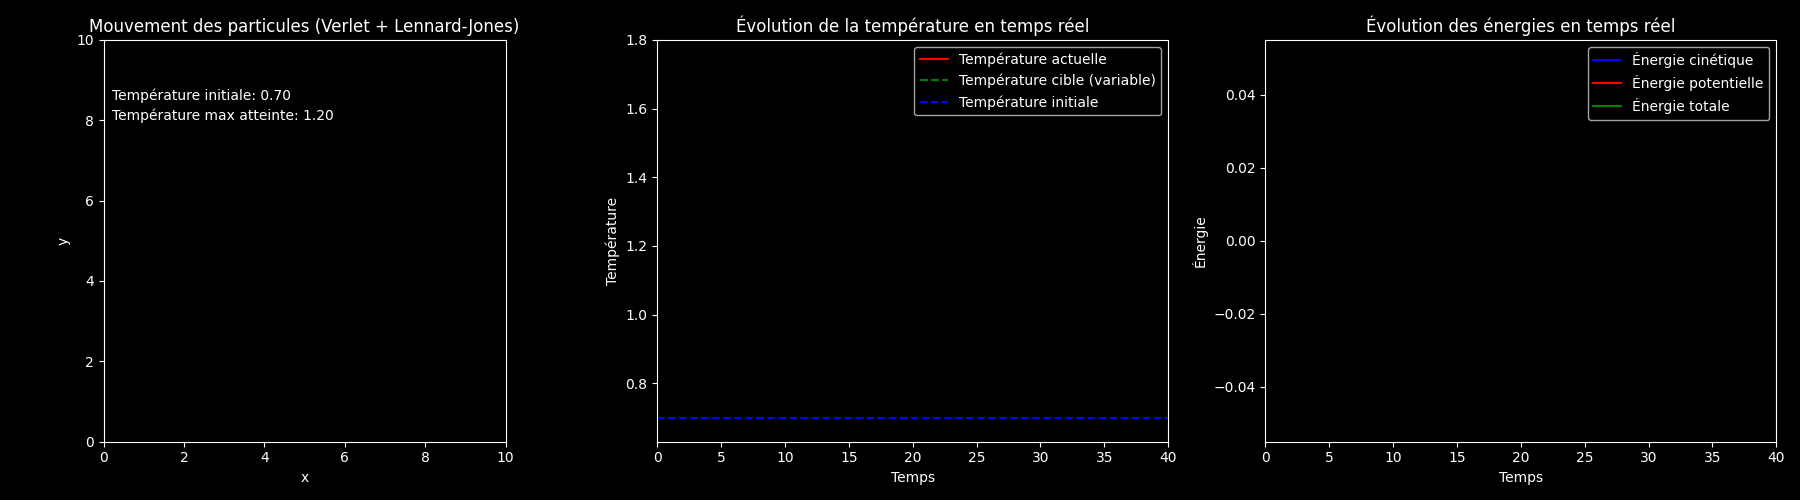

In [3]:
# -*- coding: utf-8 -*-
"""
Created on Tue Apr 15 21:45:00 2025

@author: AD
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random
from interface import Interface
import time  # Import time module for timing
%matplotlib widget

# Global timer start
global_start_time = time.time()

# Timer for constants and initialization
init_start_time = time.time()

# ----- Constantes -----
profondeur_puits_LJ = 1.0         # Profondeur du puits de potentiel de Lennard-Jones (epsilon)
distance_sigma_LJ = 1.0           # Distance à laquelle le potentiel de Lennard-Jones est nul (sigma)
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 10.0          # Taille de la boîte de simulation (carrée)
masse_particule = 1.0             # Masse des particules
constante_Boltzmann = 1.0         # Constante de Boltzmann (kB)
masse_thermostat = 5.0            # Masse du thermostat de Nose-Hoover (Q)
frequence_regulation_temperature = 1 # Fréquence de mise à jour du thermostat (en pas de temps)

# ----- Paramètres de simulation -----
rayon_coupure_LJ = 2.5 * distance_sigma_LJ   # Rayon de coupure pour le potentiel
taille_boite_simu = 10.0          # Taille de la boîte de simulation (carrée)
temperature_initiale = 0.7      # Température initiale (T_init)
temperature_max = 1.2          # (T_max)
nombre_particules = 36            # Nombre de particules (npart)
temps_debut = 0.0               # Temps initial (temps_initial)
temps_fin = 40.0               # Temps final (temps_final)
nombre_pas_temps = 3000         # Nombre d'itérations (nombre_iterations)
pas_temps = (temps_fin - temps_debut) / nombre_pas_temps   # Pas de temps (pas_de_temps)

# ----- Paramètres pour la liste de voisins -----
frequence_maj_voisins = 20
facteur_distance_voisinage = 3.0 * rayon_coupure_LJ
distance_voisinage_max = facteur_distance_voisinage * rayon_coupure_LJ
liste_voisins_particules = [[] for _ in range(nombre_particules)] # Initialisation vide (liste_voisins)


# ----- Création du profil de température cible en fonction du temps -----
temps_ajustement = np.linspace(temps_debut, temps_fin, nombre_pas_temps)
temperature_cible_tab = np.zeros_like(temps_ajustement)

phase1_fin = int(0.2 * nombre_pas_temps)
phase2_fin = int(0.4 * nombre_pas_temps)
phase3_fin = int(0.6 * nombre_pas_temps)
phase4_fin = nombre_pas_temps

temperature_cible_tab[:phase1_fin] = np.linspace(temperature_initiale, temperature_max, phase1_fin)
temperature_cible_tab[phase1_fin:phase2_fin] = temperature_max
temperature_cible_tab[phase2_fin:phase3_fin] = np.linspace(temperature_max, temperature_initiale, phase3_fin - phase2_fin)
temperature_cible_tab[phase3_fin:phase4_fin] = temperature_initiale

# Conversion de la température cible en énergie cinétique cible
energie_cinetique_cible_tab = nombre_particules * constante_Boltzmann * temperature_cible_tab



# ----- Initialisation des données -----
simulation_number = random.randint(1,20)
np.random.seed(simulation_number)

positions_particules = np.zeros((nombre_pas_temps, nombre_particules, 2))
vitesses_particules = np.zeros((nombre_pas_temps, nombre_particules, 2))
accelerations_particules = np.zeros((nombre_particules, 2))


# Conditions initiales : positions sur une grille carrée
cote_grille = int(np.sqrt(nombre_particules))
if cote_grille * cote_grille != nombre_particules:
    raise ValueError("Le nombre de particules doit être un carré parfait pour l'initialisation sur une grille carrée.")
espacement_grille = taille_boite_simu / cote_grille
x_grille, y_grille = np.meshgrid(np.arange(cote_grille) * espacement_grille + espacement_grille / 2, np.arange(cote_grille) * espacement_grille + espacement_grille / 2)
positions_particules[0] = np.column_stack((x_grille.ravel(), y_grille.ravel()))


# Initialisation des vitesses
vitesse_cible_init = np.sqrt(2 * constante_Boltzmann * temperature_initiale / masse_particule)
theta = 2 * np.pi * np.random.rand(nombre_particules)
vitesses_particules[0, :, 0] = vitesse_cible_init * np.cos(theta)
vitesses_particules[0, :, 1] = vitesse_cible_init * np.sin(theta)

# Suppression du mouvement du centre de masse initial
vitesse_centre_masse_initial = np.sum(vitesses_particules[0], axis=0) / nombre_particules
vitesses_particules[0] -= vitesse_centre_masse_initial


# Pré-calcul des constantes de Lennard-Jones
sigma_LJ_carre = distance_sigma_LJ**2
sigma_LJ_sixieme = sigma_LJ_carre**3
sigma_LJ_douzieme = sigma_LJ_sixieme**2
facteur_force_LJ = 24 * profondeur_puits_LJ
facteur_potentiel_LJ = 4 * profondeur_puits_LJ
rayon_coupure_carre_LJ = rayon_coupure_LJ**2

def mettre_a_jour_voisins(positions_actuelles, taille_boite, distance_voisinage):
    nombre_particules_local = len(positions_actuelles)
    voisins_local = [[] for _ in range(nombre_particules_local)]
    distance_voisinage_carre = distance_voisinage**2

    for i in range(nombre_particules_local):
        for j in range(i + 1, nombre_particules_local):
            dx = positions_actuelles[i] - positions_actuelles[j]
            dx = dx - taille_boite * np.round(dx / taille_boite)
            distance_carre = np.dot(dx, dx)
            if distance_carre < distance_voisinage_carre:
                voisins_local[i].append(j)
                voisins_local[j].append(i)
    return voisins_local

def forces_LJ_avec_voisins(positions, taille_boite, rayon_coupure_carre, profondeur_puits, sigma_carre, sigma_sixieme, facteur_force, liste_voisins):
    nombre_particules_local = len(positions)
    forces_lj = np.zeros_like(positions)

    for i in range(nombre_particules_local):
        for j_voisin in liste_voisins[i]:
            dx = positions[i] - positions[j_voisin]
            dx = dx - taille_boite * np.round(dx / taille_boite)
            distance_carre = np.dot(dx, dx)
            if 0 < distance_carre < rayon_coupure_carre:
                distance_carre_inv = 1.0 / distance_carre
                distance_sixieme_inv = sigma_sixieme * (distance_carre_inv)**3
                distance_douzieme_inv = distance_sixieme_inv**2
                force_scalaire = facteur_force * (2 * distance_douzieme_inv - distance_sixieme_inv) * np.sqrt(distance_carre_inv)
                force_ij = force_scalaire * dx
                forces_lj[i] += force_ij
                forces_lj[j_voisin] -= force_ij
    return forces_lj

def potentiel_LJ_avec_voisins(positions, taille_boite, rayon_coupure_carre, profondeur_puits, sigma_sixieme, sigma_douzieme, facteur_potentiel, liste_voisins):
    nombre_particules_local = len(positions)
    energie_potentielle_totale = 0.0
    for i in range(nombre_particules_local):
        for j_voisin in liste_voisins[i]:
            if j_voisin > i:
                dx = positions[i] - positions[j_voisin]
                dx = dx - taille_boite * np.round(dx / taille_boite)
                distance_carre = np.dot(dx, dx)
                if 0 < distance_carre < rayon_coupure_carre:
                    distance_sixieme_inv = sigma_sixieme * (1.0 / distance_carre)**3
                    distance_douzieme_inv = sigma_douzieme * (1.0 / distance_carre)**6
                    energie_potentielle_totale += facteur_potentiel * (distance_douzieme_inv - distance_sixieme_inv)
    return energie_potentielle_totale

# Initialisation des accélérations
liste_voisins_particules = mettre_a_jour_voisins(positions_particules[0], taille_boite_simu, distance_voisinage_max)
forces_initiales = forces_LJ_avec_voisins(positions_particules[0], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_carre, sigma_LJ_sixieme, facteur_force_LJ, liste_voisins_particules)
accelerations_particules = forces_initiales / masse_particule

# Tableaux pour stocker la température et l'énergie à chaque itération
temperatures = np.zeros(nombre_pas_temps)
energies_cinetiques = np.zeros(nombre_pas_temps)
energies_potentielles = np.zeros(nombre_pas_temps)
energies_totales = np.zeros(nombre_pas_temps)
temps = np.linspace(temps_debut, temps_fin, nombre_pas_temps)

# End of first timer
init_end_time = time.time()
init_time = init_end_time - init_start_time

# Timer for functions and initializations
func_start_time = time.time()

# ----- Intégration par l'algorithme de Verlet -----
# Initialize timing variables for if loops
voisins_time_total = 0
forces_time_total = 0
temp_reg_time_total = 0
voisins_count = 0
forces_count = 0
temp_reg_count = 0
# Initialize timing variables for forces and potential
forces_calc_time_total = 0
potential_calc_time_total = 0
forces_calc_count = 0
potential_calc_count = 0

# Initialize Nose-Hoover variables
zeta = 0.0  # Thermostat variable
zeta_point = 0.0  # Time derivative of thermostat variable

# ----- Parameters for Latent Heat Feature -----
temperature_transition = 1.0         # Temperature where phase change occurs
latent_heat_value = 2.0              # Latent heat absorbed/released per particle
transition_done = np.zeros(nombre_particules, dtype=bool)  # Track transitions


for i in range(nombre_pas_temps - 1):
    # Timer for neighbor list update
    if (i + 1) % frequence_maj_voisins == 0:
        voisins_start_time = time.time()
        liste_voisins_particules = mettre_a_jour_voisins(positions_particules[i], taille_boite_simu, distance_voisinage_max)
        voisins_end_time = time.time()
        voisins_time_total += (voisins_end_time - voisins_start_time)
        voisins_count += 1

    # Timer for force calculation
    forces_start_time = time.time()
    
    # Timer for forces calculation
    forces_calc_start_time = time.time()
    forces_lj = forces_LJ_avec_voisins(positions_particules[i], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_carre, sigma_LJ_sixieme, facteur_force_LJ, liste_voisins_particules)
    forces_calc_end_time = time.time()
    forces_calc_time_total += (forces_calc_end_time - forces_calc_start_time)
    forces_calc_count += 1
    
    # Timer for potential energy calculation
    potential_calc_start_time = time.time()
    energie_potentielle_instantannee = potentiel_LJ_avec_voisins(positions_particules[i], taille_boite_simu, rayon_coupure_carre_LJ, profondeur_puits_LJ, sigma_LJ_sixieme, sigma_LJ_douzieme, facteur_potentiel_LJ, liste_voisins_particules)
    potential_calc_end_time = time.time()
    potential_calc_time_total += (potential_calc_end_time - potential_calc_start_time)
    potential_calc_count += 1
    
    forces_end_time = time.time()
    forces_time_total += (forces_end_time - forces_start_time)
    forces_count += 1

    # Calcul de l'énergie cinétique instantanée
    energie_cinetique_instantannee = 0.5 * masse_particule * np.sum(vitesses_particules[i]**2)
    energies_cinetiques[i] = energie_cinetique_instantannee
    temperatures[i] = energie_cinetique_instantannee / (nombre_particules * constante_Boltzmann)

    # Nose-Hoover thermostat update
    # ----- Apply Latent Heat Absorption -----
    if (i + 1) % frequence_regulation_temperature == 0:
        for idx in range(nombre_particules):
            T_current = 0.5 * masse_particule * np.sum(vitesses_particules[i, idx]**2) / constante_Boltzmann
            if not transition_done[idx] and T_current >= temperature_transition:
                # Increase kinetic energy by latent heat (converted to velocity change)
                additional_energy = latent_heat_value
                current_velocity_sq = np.sum(vitesses_particules[i, idx]**2)
                current_energy = 0.5 * masse_particule * current_velocity_sq
                new_energy = current_energy + additional_energy
                scale_factor = np.sqrt(new_energy / current_energy)
                vitesses_particules[i, idx] *= scale_factor
                transition_done[idx] = True

        temp_reg_start_time = time.time()
        # Calculate current temperature
        T_current = temperatures[i]
        # Update zeta_point (thermostat equation of motion)
        zeta_point = (T_current - temperature_cible_tab[i]) / masse_thermostat
        # Update zeta
        zeta += zeta_point * pas_temps
        # Apply thermostat to velocities
        vitesses_particules[i] *= np.exp(-zeta * pas_temps)
        temp_reg_end_time = time.time()
        temp_reg_time_total += (temp_reg_end_time - temp_reg_start_time)
        temp_reg_count += 1

    # Mise à jour des accélérations en utilisant le principe de Newton avec le terme de Nose-Hoover
    accelerations_particules = (forces_lj - zeta * vitesses_particules[i]) / masse_particule

    # Mise à jour des vitesses (Verlet velocity)
    vitesses_particules[i+1] = vitesses_particules[i] + pas_temps * accelerations_particules

    # Mise à jour des positions (Verlet velocity)
    positions_particules[i+1] = positions_particules[i] + pas_temps * vitesses_particules[i+1]

    # Conditions périodiques : repliement dans la boîte
    positions_particules[i+1] %= taille_boite_simu

    # Recalcul de la liste des voisins
    if (i + 1) % frequence_maj_voisins == 0:
        liste_voisins_particules = mettre_a_jour_voisins(positions_particules[i+1], taille_boite_simu, distance_voisinage_max)
    
    # ----- Calcul de l'énergie -----
    energie_cinetique_instantannee_next = 0.5 * masse_particule * np.sum(vitesses_particules[i+1]**2)
    energie_totale_instantanee = energie_cinetique_instantannee_next + energie_potentielle_instantannee

    temperatures[i+1] = energie_cinetique_instantannee_next / (nombre_particules * constante_Boltzmann)
    energies_cinetiques[i+1] = energie_cinetique_instantannee_next
    energies_potentielles[i+1] = energie_potentielle_instantannee
    energies_totales[i+1] = energie_totale_instantanee

# End of second timer
func_end_time = time.time()
func_time = func_end_time - func_start_time


# Timer for interface creation and display
interface_start_time = time.time()

# Create and show interface
interface = Interface(
    positions_particules=positions_particules,
    vitesses_particules=vitesses_particules,
    temperatures=temperatures,
    energies_cinetiques=energies_cinetiques,
    energies_potentielles=energies_potentielles,
    energies_totales=energies_totales,
    temperature_cible_tab=temperature_cible_tab,
    temps=temps,
    taille_boite_simu=taille_boite_simu,
    temperature_initiale=temperature_initiale,
    temperature_max=temperature_max
)

# End of interface timer
interface_end_time = time.time()
interface_time = interface_end_time - interface_start_time

# Global timer end
global_end_time = time.time()
global_time = global_end_time - global_start_time

# Print timing results
print("\n=== Timing Results ===")
print(f"Initialization time (constants and setup): {init_time:.6f} seconds")
print(f"Functions and initializations time: {func_time:.6f} seconds")
print(f"\n=== Verlet Integration Loop Timing ===")
print(f"Neighbor list updates (total time): {voisins_time_total:.6f} seconds")
print(f"Neighbor list updates (average time): {voisins_time_total/voisins_count:.6f} seconds")
print(f"\nForce calculations section:")
print(f"  Total section time: {forces_time_total:.6f} seconds")
print(f"  Forces calculation (total time): {forces_calc_time_total:.6f} seconds")
print(f"  Forces calculation (average time): {forces_calc_time_total/forces_calc_count:.6f} seconds")
print(f"  Potential energy calculation (total time): {potential_calc_time_total:.6f} seconds")
print(f"  Potential energy calculation (average time): {potential_calc_time_total/potential_calc_count:.6f} seconds")
print(f"\nTemperature regulation (total time): {temp_reg_time_total:.6f} seconds")
print(f"Temperature regulation (average time): {temp_reg_time_total/temp_reg_count:.6f} seconds")
print(f"\nInterface creation and display time: {interface_time:.6f} seconds")
print(f"Total execution time: {global_time:.6f} seconds")

interface.show()